<a href="https://colab.research.google.com/github/nayverp/Ciencia-de-datos-/blob/main/Prueba.de.diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import pandas as pd

ruta = "/content/drive/MyDrive/Proyecto/diabetes.csv"
df = pd.read_csv(ruta)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Proyecto: Predicción de diabetes

## Agenda del análisis

1. Cargar el dataset.
2. Revisar el significado de cada variable o feature.
3. Identificar el tipo de dato de cada variable.
4. Realizar un análisis exploratorio de datos, también llamado EDA.
5. Revisar datos nulos, duplicados y valores en cero que pueden representar errores.
6. Limpiar los datos reemplazando valores incorrectos.
7. Analizar el comportamiento de las variables.
8. Analizar la relación entre las variables y la diabetes.
9. Entrenar diferentes modelos de clasificación.
10. Comparar Random Forest con otros modelos.
11. Probar Random Forest tres veces con diferentes parámetros.
12. Identificar las variables más importantes para predecir diabetes.
13. Concluir cuál modelo tuvo mejor rendimiento.

In [25]:
diccionario_features = pd.DataFrame({
    "Variable": [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
        "Outcome"
    ],
    "Significado": [
        "Número de embarazos registrados en la persona",
        "Nivel de glucosa en la sangre",
        "Presión arterial diastólica",
        "Grosor del pliegue cutáneo del tríceps",
        "Nivel de insulina en sangre",
        "Índice de masa corporal",
        "Función de pedigrí de diabetes, relacionada con antecedentes familiares",
        "Edad de la persona",
        "Variable objetivo que indica si la persona tiene diabetes o no"
    ],
    "Tipo de dato": [
        "Numérico entero",
        "Numérico entero",
        "Numérico entero",
        "Numérico entero",
        "Numérico entero",
        "Numérico decimal",
        "Numérico decimal",
        "Numérico entero",
        "Categórico binario"
    ],
    "Valores típicos / interpretación": [
        "0 a 17 embarazos aproximadamente",
        "Valores comunes entre 70 y 140",
        "Valores comunes entre 60 y 90",
        "Valores comunes entre 10 y 50",
        "Puede variar mucho; el valor 0 puede representar dato faltante",
        "Normal: 18.5 a 24.9; sobrepeso: 25 a 29.9; obesidad: 30 o más",
        "Valores altos pueden indicar mayor riesgo hereditario",
        "Generalmente desde 21 años en adelante",
        "0 = no tiene diabetes, 1 = tiene diabetes"
    ]
})

diccionario_features

,Variable,Significado,Tipo de dato,Valores típicos / interpretación
0,Pregnancies,Número de embarazos registrados en la persona,Numérico entero,0 a 17 embarazos aproximadamente
1,Glucose,Nivel de glucosa en la sangre,Numérico entero,Valores comunes entre 70 y 140
2,BloodPressure,Presión arterial diastólica,Numérico entero,Valores comunes entre 60 y 90
3,SkinThickness,Grosor del pliegue cutáneo del tríceps,Numérico entero,Valores comunes entre 10 y 50
4,Insulin,Nivel de insulina en sangre,Numérico entero,Puede variar mucho; el valor 0 puede represent...
5,BMI,Índice de masa corporal,Numérico decimal,Normal: 18.5 a 24.9; sobrepeso: 25 a 29.9; obe...
6,DiabetesPedigreeFunction,"Función de pedigrí de diabetes, relacionada co...",Numérico decimal,Valores altos pueden indicar mayor riesgo here...
7,Age,Edad de la persona,Numérico entero,Generalmente desde 21 años en adelante
8,Outcome,Variable objetivo que indica si la persona tie...,Categórico binario,"0 = no tiene diabetes, 1 = tiene diabetes"


In [26]:
# Librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
print("Tamaño del dataset:")
print(df.shape)

print("\nInformación general del dataset:")
df.info()

print("\nEstadísticas descriptivas:")
df.describe()

Tamaño del dataset:
(768, 9)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Estadísticas descriptivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [28]:
print("Datos nulos por columna:")
print(df.isnull().sum())

print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())

Datos nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Cantidad de filas duplicadas:
0


¿Qué hace?

Cuenta datos vacíos,
Cuenta filas repetidas

In [29]:
conteo_diabetes = df["Outcome"].value_counts()
porcentaje_diabetes = df["Outcome"].value_counts(normalize=True) * 100

tabla_outcome = pd.DataFrame({
    "Cantidad": conteo_diabetes,
    "Porcentaje": porcentaje_diabetes.round(2)
})

tabla_outcome

,Cantidad,Porcentaje
Outcome,,
0,500,65.1
1,268,34.9


¿Qué hace?

Cuenta:

cuántos tienen diabetes (1)

cuántos no (0)

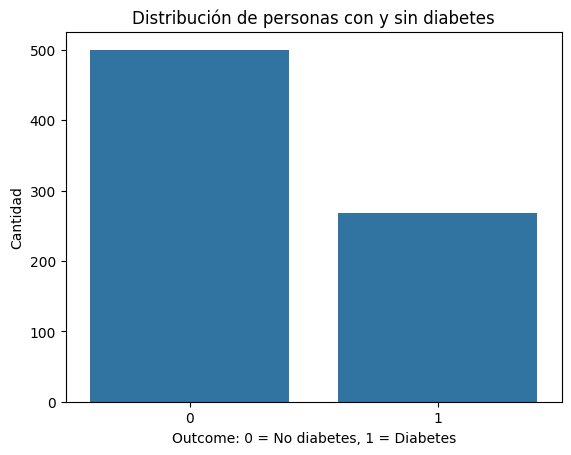

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Outcome", data=df)
plt.title("Distribución de personas con y sin diabetes")
plt.xlabel("Outcome: 0 = No diabetes, 1 = Diabetes")
plt.ylabel("Cantidad")
plt.show()

¿Qué hace?

Muestra lo anterior pero visualmente.

In [31]:
columnas_con_ceros_invalidos = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

ceros_invalidos = (df[columnas_con_ceros_invalidos] == 0).sum()
ceros_invalidos

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


 detecta: Valores 0 en variables como:

glucosa, presión

Es un problema, porque  
una persona viva NO puede tener glucosa = 0

En Conclusión  
Esos ceros en realidad son: datos faltantes mal registrados

In [32]:
df_limpio = df.copy()

for columna in columnas_con_ceros_invalidos:
    mediana = df_limpio[df_limpio[columna] != 0][columna].median()
    df_limpio[columna] = df_limpio[columna].replace(0, mediana)

df_limpio.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Crea copia para no dañar el original.

tambien:
Cambia ceros por la mediana.

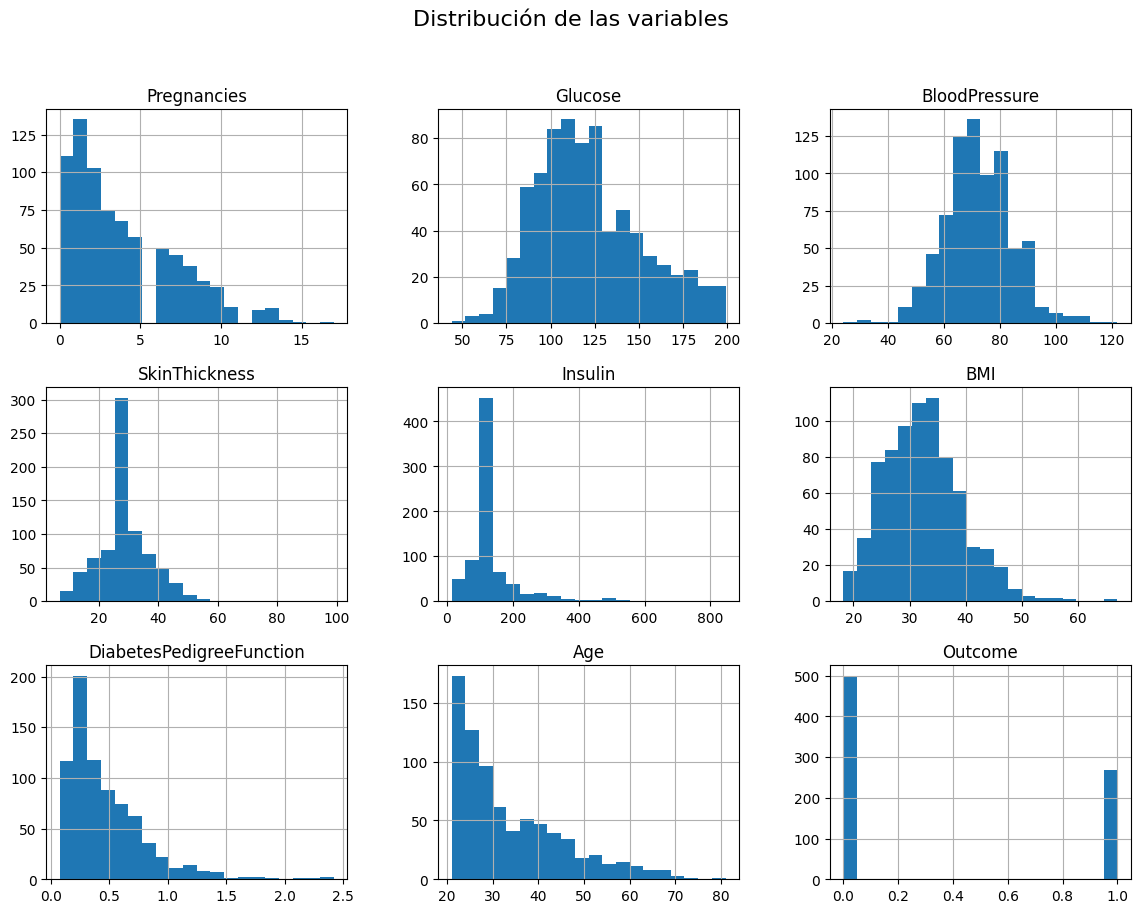

In [33]:
df_limpio.hist(figsize=(14,10), bins=20)
plt.suptitle("Distribución de las variables", fontsize=16)
plt.show()

Esta nos muestra
Cómo se distribuyen los datos.

 Ejemplo:

normal  
sesgada

 Sirve para entender el comportamiento de cada variable.

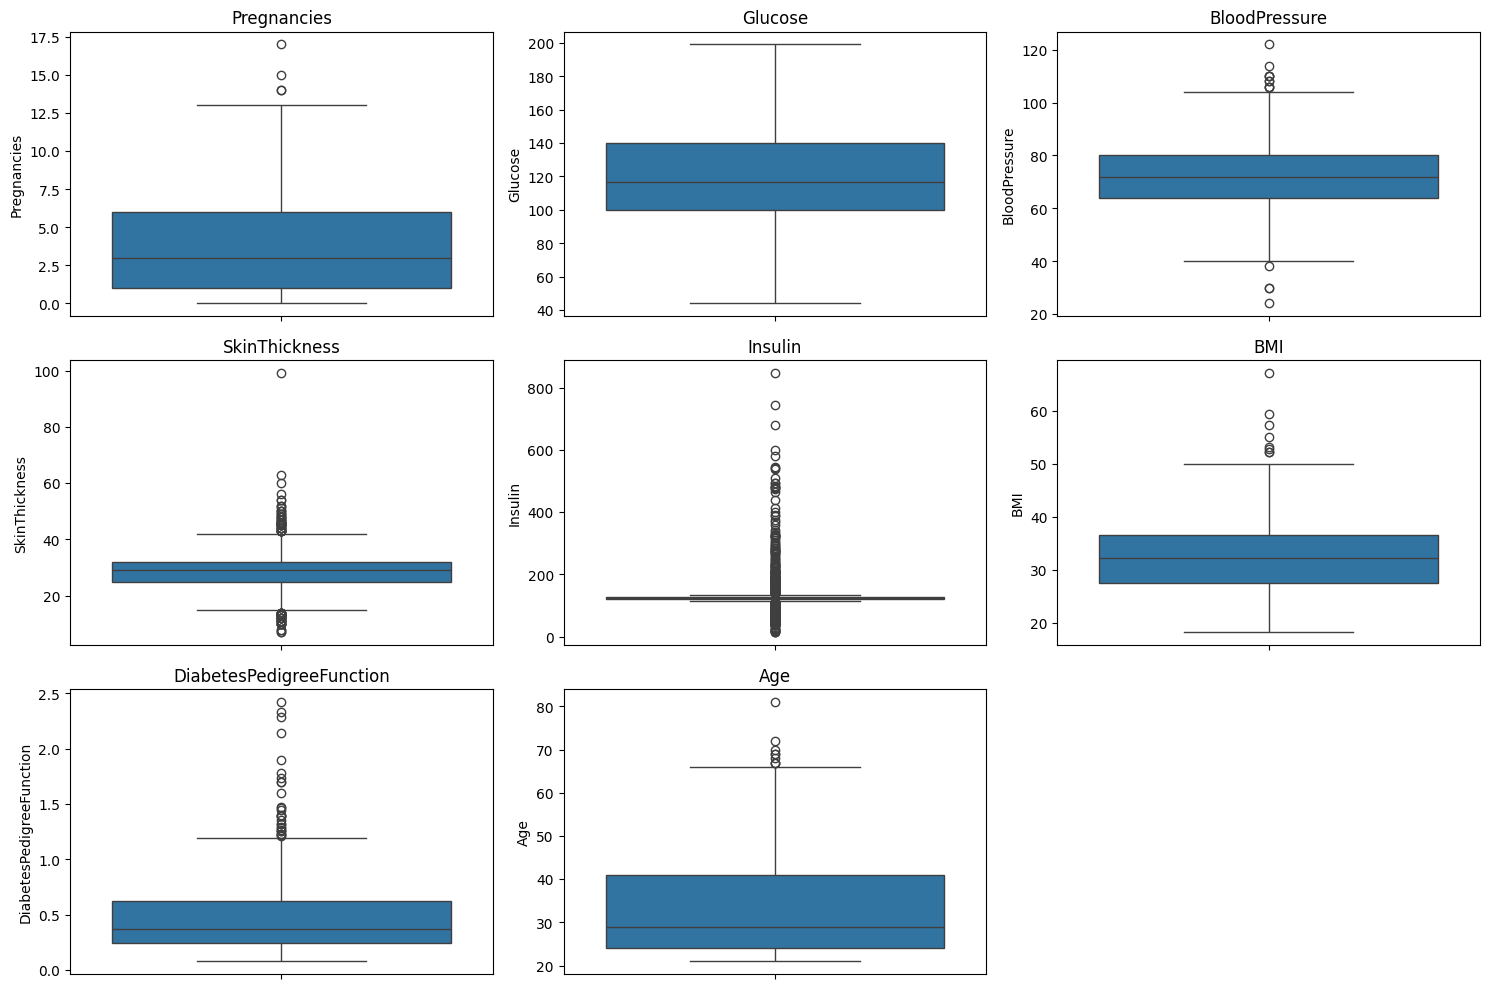

In [34]:
variables = df_limpio.drop("Outcome", axis=1).columns

plt.figure(figsize=(15,10))

for i, columna in enumerate(variables, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_limpio[columna])
    plt.title(columna)

plt.tight_layout()
plt.show()

Qué hace;  
Detectan valores extremos.

Ejemplo

BMI = 70 → sospechoso

Esto importa porque los outliers pueden:

confundir al modelo, distorsionar resultados

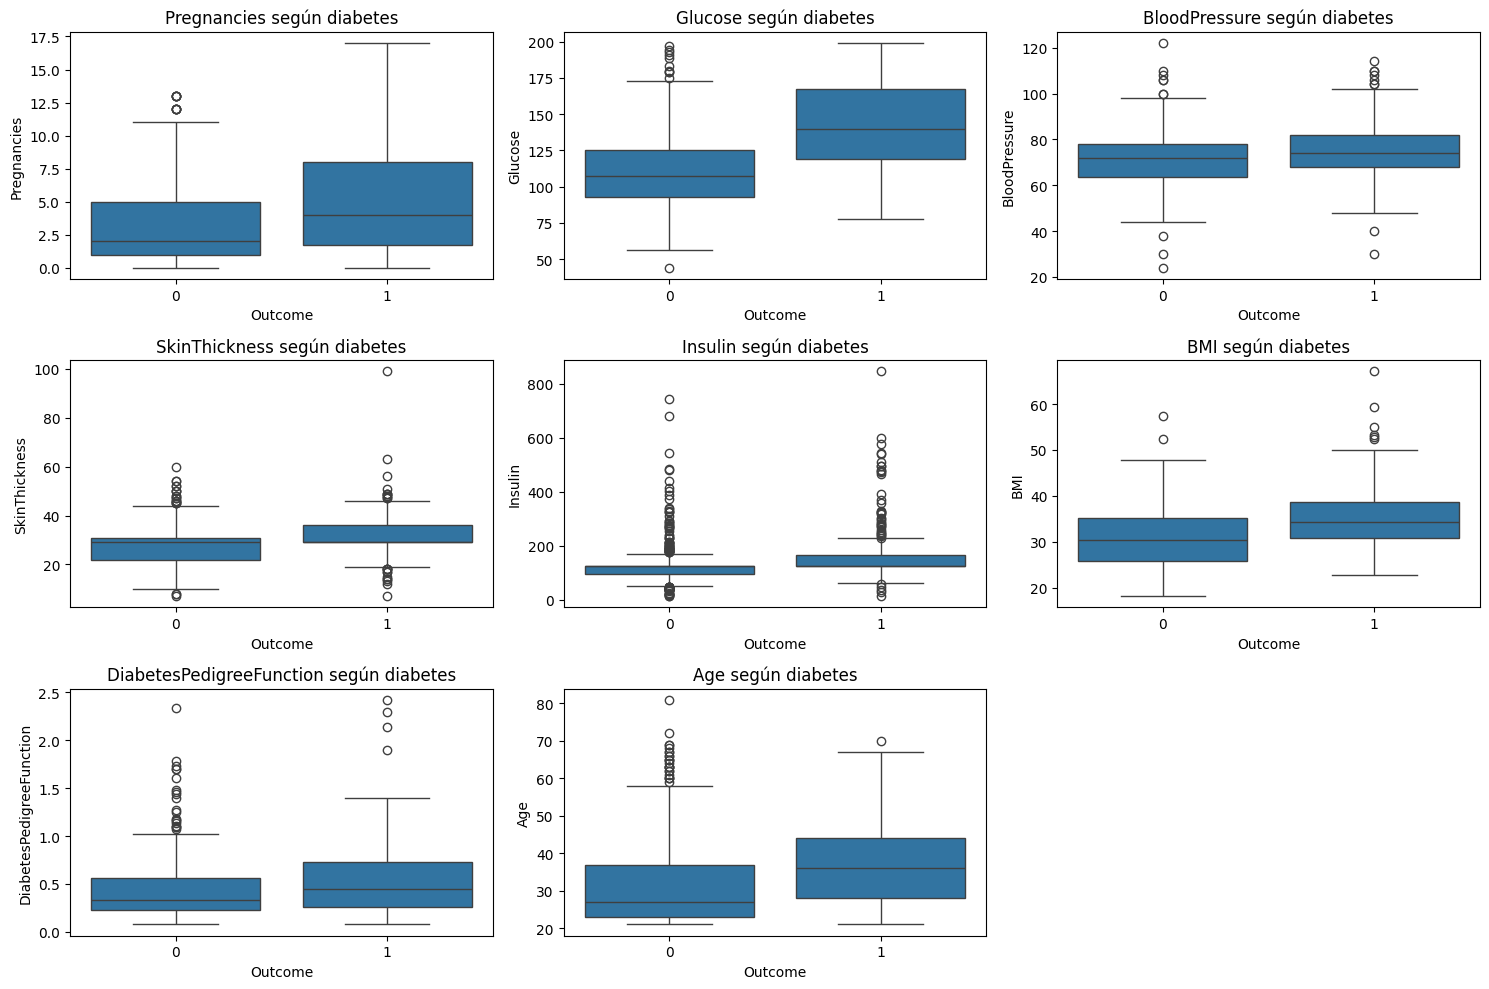

In [35]:
plt.figure(figsize=(15,10))

for i, columna in enumerate(variables, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x="Outcome", y=columna, data=df_limpio)
    plt.title(f"{columna} según diabetes")

plt.tight_layout()
plt.show()

Qué hace:   
Compara variables con diabetes.

Ejemplo:

personas con diabetes → mayor glucosa

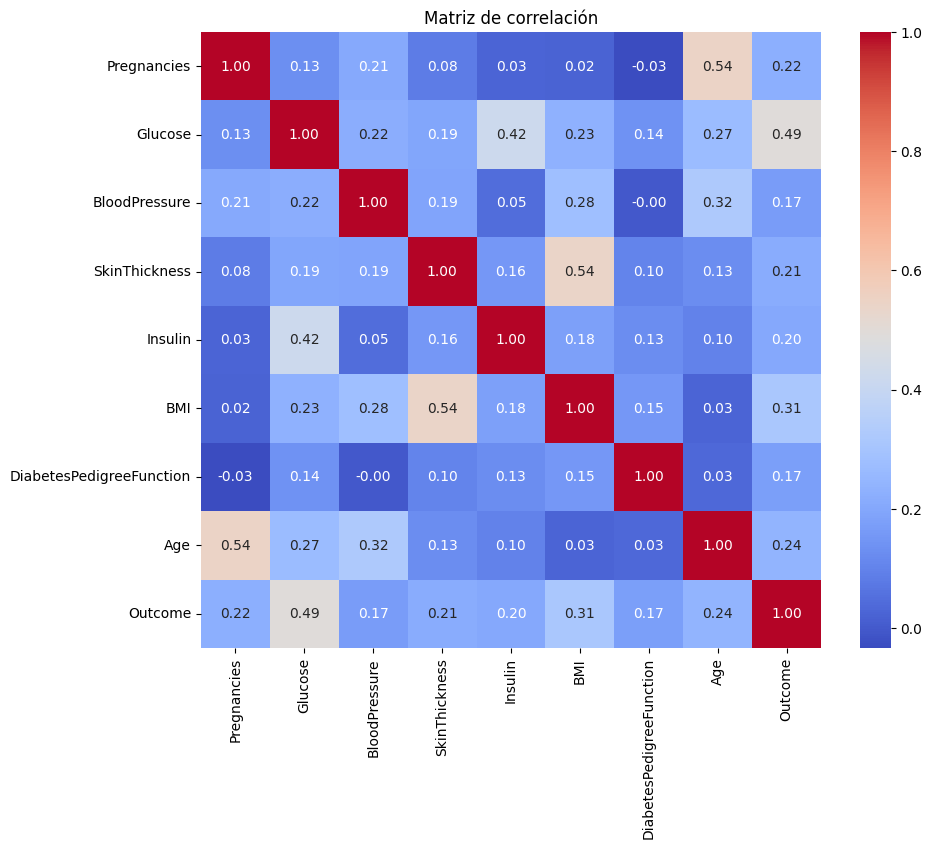

In [36]:
plt.figure(figsize=(10,8))
sns.heatmap(df_limpio.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

esto hace la relación entre variables (-1 a 1)

 Ejemplo:

1 → relación fuerte positiva

0 → sin relación

In [37]:
X = df_limpio.drop("Outcome", axis=1)
y = df_limpio["Outcome"]

Qué hace

X → variables de entrada

y → lo que quieres predecir

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Qué hace

Divide tus datos en entrenamiento y prueba

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

Qué hace: importa lo necesario para

construir modelos

entrenarlos

evaluarlos


In [40]:
random_forests = {
    "Random Forest 1": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42
    ),

    "Random Forest 2": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ),

    "Random Forest 3": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        random_state=42
    )
}

resultados_rf = []

for nombre, modelo in random_forests.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados_rf.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

df_resultados_rf = pd.DataFrame(resultados_rf)
df_resultados_rf

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest 1,0.779221,0.727273,0.592593,0.653061,0.819167
1,Random Forest 2,0.740260,0.659091,0.537037,0.591837,0.807407
2,Random Forest 3,0.740260,0.645833,0.574074,0.607843,0.805556


En este bloque se probo diferentes configuraciones del modelo Random Forest con el objetivo de mejorar su rendimiento

 Ajustamos parámetros como:

número de árboles

profundidad máxima

mínimo de muestras para dividir

Sabiendo que el mejor es el RF1 porque su F1-score es mas alto lo que tiene un mejor equilibrio

In [41]:
mejor_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

mejor_rf.fit(X_train, y_train)

importancias = mejor_rf.feature_importances_
variables = X.columns

df_importancia = pd.DataFrame({
    "Variable": variables,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

df_importancia

,Variable,Importancia
1,Glucose,0.296587
5,BMI,0.167074
7,Age,0.120137
6,DiabetesPedigreeFunction,0.113457
4,Insulin,0.094252
0,Pregnancies,0.071341
2,BloodPressure,0.070240
3,SkinThickness,0.066911


Después de hacer mejor el modelo, lo entrené con la mejor configuración y analicé la importancia de las variables para entender qué factores influyen más en la predicción de la diabetes

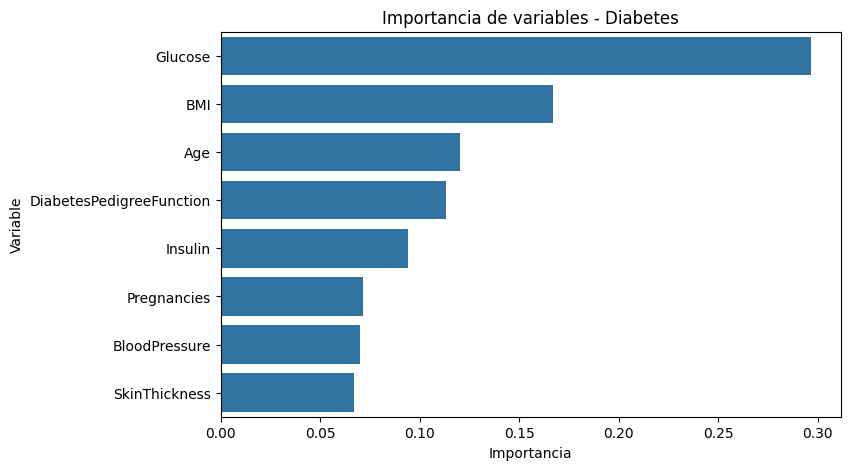

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importancia", y="Variable", data=df_importancia)
plt.title("Importancia de variables - Diabetes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()